Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)


Load Datasets

In [10]:
monday_path = "../data/raw/Monday-WorkingHours.pcap_ISCX.csv"
friday_path = "../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df_monday = pd.read_csv(monday_path)
df_friday = pd.read_csv(friday_path)

print("Monday shape:", df_monday.shape)
print("Friday shape:", df_friday.shape)

Monday shape: (529918, 79)
Friday shape: (225745, 79)


Combine Datasets

In [15]:
print(df.columns.tolist())
df_monday.columns = df_monday.columns.str.strip()
df_friday.columns = df_friday.columns.str.strip()

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [16]:
df = pd.concat([df_monday, df_friday], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Unique labels:", df["Label"].unique())


Combined dataset shape: (755663, 79)
Unique labels: ['BENIGN' 'DDoS']


Class Distribution

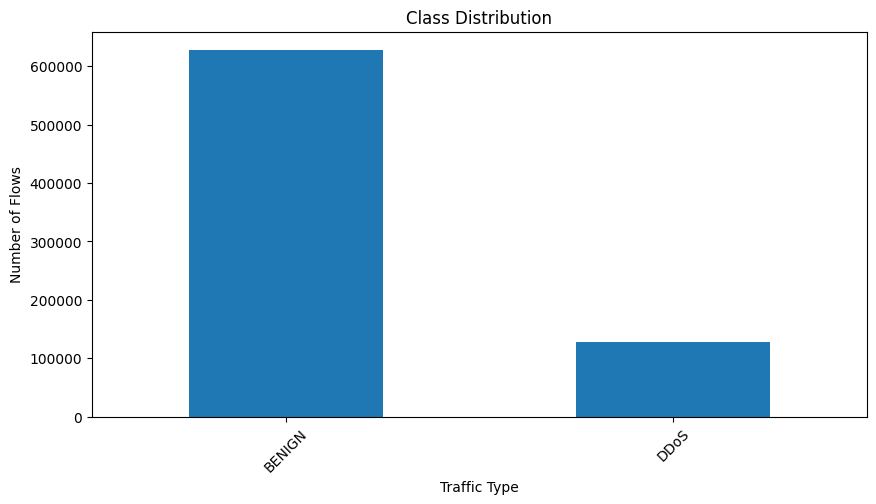

Label
BENIGN    83.057659
DDoS      16.942341
Name: count, dtype: float64

In [17]:
label_counts = df["Label"].value_counts()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Number of Flows")
plt.xlabel("Traffic Type")
plt.xticks(rotation=45)
plt.show()

label_percent = (label_counts / label_counts.sum()) * 100
label_percent


Missing & Infinite Values

In [18]:
# Replace infinite values with NaN for inspection
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing_values = df.isnull().sum()
missing_features = missing_values[missing_values > 0].sort_values(ascending=False)

missing_features.head(10)


Flow Bytes/s      471
Flow Packets/s    471
dtype: int64

Drop Identifier Columns

In [19]:
id_cols = ["Flow ID", "Source IP", "Destination IP", 
           "Timestamp", "Source Port", "Destination Port"]

df_clean = df.drop(columns=[col for col in id_cols if col in df.columns])


Feature Correlation Heatmap

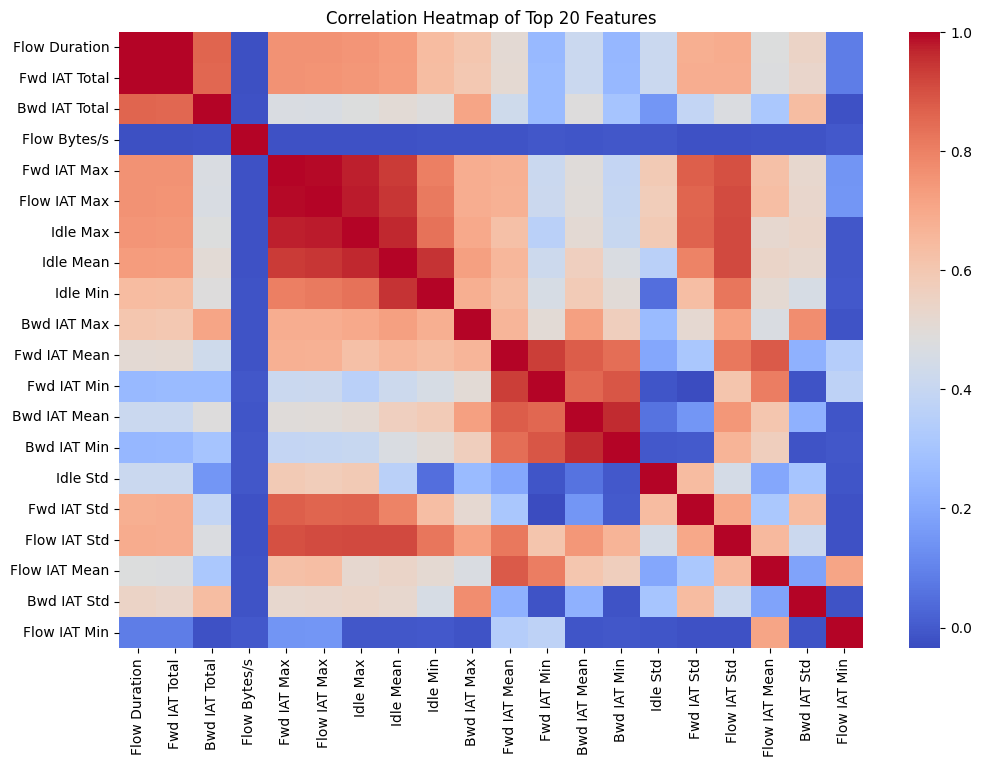

In [20]:
numeric_df = df_clean.select_dtypes(include=np.number)

# Select top 20 features by variance
top_features = numeric_df.var().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df[top_features].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of Top 20 Features")
plt.show()

Feature Distribution Comparison

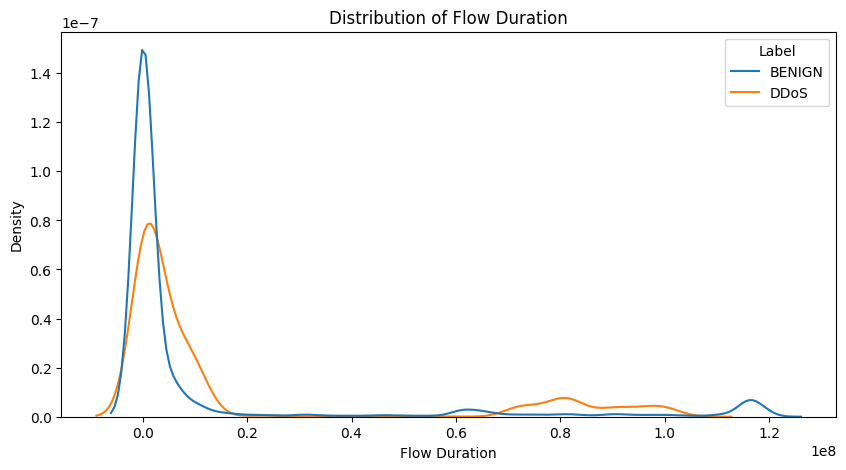

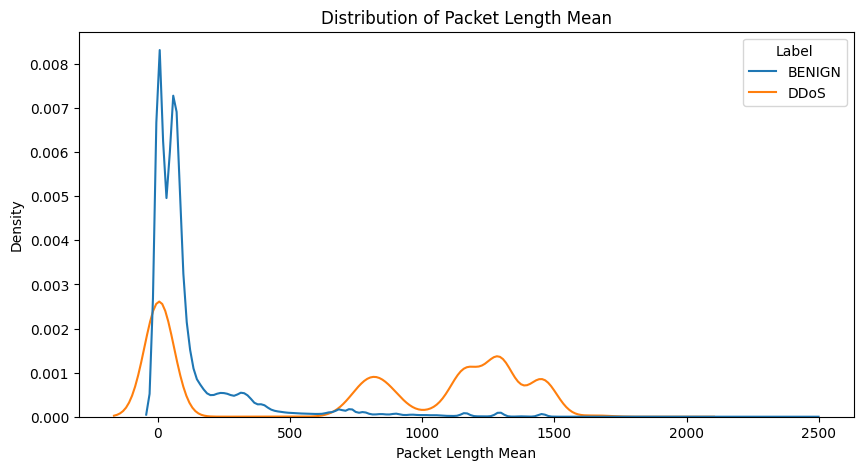

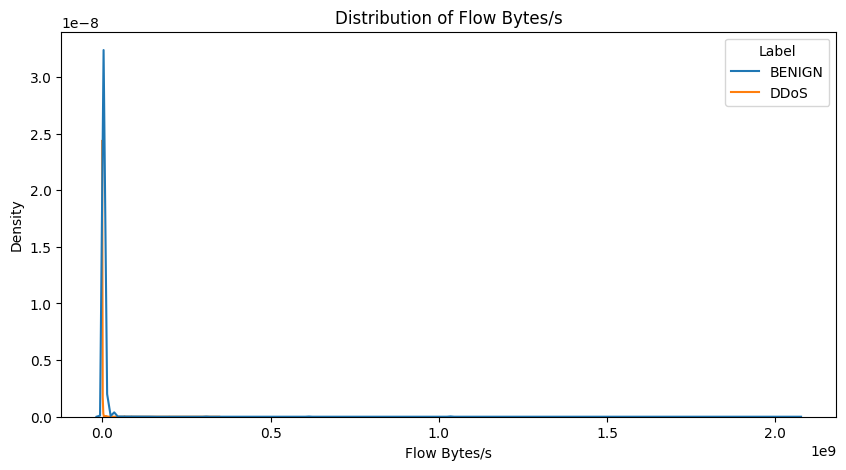

In [21]:
features_to_plot = ["Flow Duration", "Packet Length Mean", "Flow Bytes/s"]

for feature in features_to_plot:
    plt.figure()
    sns.kdeplot(
        data=df_clean,
        x=feature,
        hue="Label",
        common_norm=False
    )
    plt.title(f"Distribution of {feature}")
    plt.show()


EDA Summary:

The exploratory data analysis highlights significant class imbalance between benign and attack traffic. Several flow-based features, such as packet length statistics and flow byte rates, exhibit distinct distribution patterns for malicious traffic. The presence of missing and infinite values necessitates a robust preprocessing pipeline. Correlation analysis reveals redundancy among certain features, suggesting the need for careful feature selection or regularization in subsequent models.